In [2]:
import joblib 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
pca = joblib.load(r'C:\Users\divya\Desktop\Team parakh\pca.pkl')
scaler = joblib.load(r'C:\Users\divya\Desktop\Team parakh\standard_scaler.pkl')
df = joblib.load(r'C:\Users\divya\Desktop\Team parakh\Parakh-task-5\cleaned_dataset.pkl')

In [4]:
x = df.iloc[:,:]

In [5]:
x = x.drop('target_career', axis=1)

In [6]:
y = df.iloc[:,33]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
x_train_pca = pca.transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

In [10]:
x_train_pca.shape

(1119, 32)

In [11]:
lr=LogisticRegression(max_iter=1000)
lr.fit(x_train_pca,y_train)
lr_pred=lr.predict(x_test_pca)

In [12]:
print("Accuracy:",accuracy_score(y_test,lr_pred))
print("Precision:",precision_score(y_test,lr_pred,average="weighted"))
print("Recall:",recall_score(y_test,lr_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,lr_pred,average="weighted"))

Accuracy: 0.8428571428571429
Precision: 0.8449660329318713
Recall: 0.8428571428571429
F1 Score: 0.8421544388360641


In [13]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train_pca,y_train)
dt_pred=dt.predict(x_test_pca)

In [14]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred, average="weighted"))
print("Recall:", recall_score(y_test, dt_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, dt_pred, average="weighted"))

Accuracy: 0.6785714285714286
Precision: 0.687341339359973
Recall: 0.6785714285714286
F1 Score: 0.6758830714294168


In [15]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_pca,y_train)
rf_pred=rf.predict(x_test_pca)

In [16]:
print("Accuracy:",accuracy_score(y_test,rf_pred))
print("Precision:",precision_score(y_test,rf_pred,average="weighted"))
print("Recall:",recall_score(y_test,rf_pred,average="weighted"))
print("F1 Score:",f1_score(y_test,rf_pred,average="weighted"))

Accuracy: 0.8357142857142857
Precision: 0.8457544951605597
Recall: 0.8357142857142857
F1 Score: 0.834382383110618


In [17]:
models={
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}
for name, pred in models.items():
    print("\n",name)
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred, average="weighted"))
    print("Recall:", recall_score(y_test, pred, average="weighted"))
    print("F1 Score:", f1_score(y_test, pred, average="weighted"))


 Logistic Regression
Accuracy: 0.8428571428571429
Precision: 0.8449660329318713
Recall: 0.8428571428571429
F1 Score: 0.8421544388360641

 Decision Tree
Accuracy: 0.6785714285714286
Precision: 0.687341339359973
Recall: 0.6785714285714286
F1 Score: 0.6758830714294168

 Random Forest
Accuracy: 0.8357142857142857
Precision: 0.8457544951605597
Recall: 0.8357142857142857
F1 Score: 0.834382383110618


In [18]:
models={
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

In [19]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.842857,0.844966,0.842857,0.842154
1,Decision Tree,0.678571,0.687341,0.678571,0.675883
2,Random Forest,0.835714,0.845754,0.835714,0.834382


In [20]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]
print(best_model)

Model        Logistic Regression
Accuracy                0.842857
Precision               0.844966
Recall                  0.842857
F1 Score                0.842154
Name: 0, dtype: object


In [21]:
import matplotlib.pyplot as plt

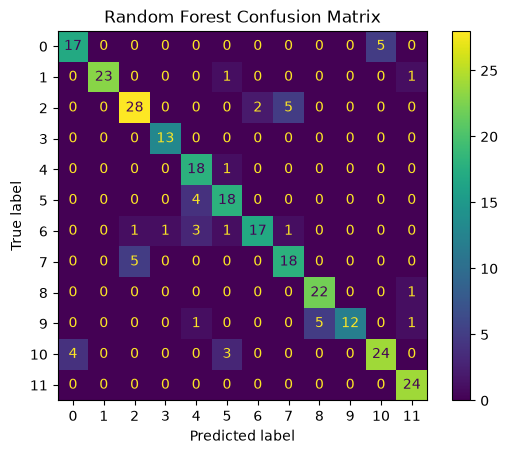

In [22]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm=confusion_matrix(y_test,rf_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Hyperparameter Tuning


#

In [23]:
from sklearn.model_selection import GridSearchCV

In [24]:
params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [25]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

In [26]:
grid.fit(x_train_pca, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [27]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [28]:
print("Best CV F1 Score:", grid.best_score_)

Best CV F1 Score: 0.8541612407514925


In [29]:
best_rf = grid.best_estimator_

In [30]:
best_rf_pred = best_rf.predict(x_test_pca)

In [31]:
print("Tuned Random Forest")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred, average="weighted"))
print("Recall:", recall_score(y_test, best_rf_pred, average="weighted"))
print("F1 Score:", f1_score(y_test, best_rf_pred, average="weighted"))

Tuned Random Forest
Accuracy: 0.8285714285714286
Precision: 0.834941669371498
Recall: 0.8285714285714286
F1 Score: 0.8272617983494689


In [32]:
print("Original Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred, average="weighted"))

print("\nTuned Random Forest")
print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("F1 Score:", f1_score(y_test, best_rf_pred, average="weighted"))

Original Random Forest
Accuracy: 0.8357142857142857
F1 Score: 0.834382383110618

Tuned Random Forest
Accuracy: 0.8285714285714286
F1 Score: 0.8272617983494689


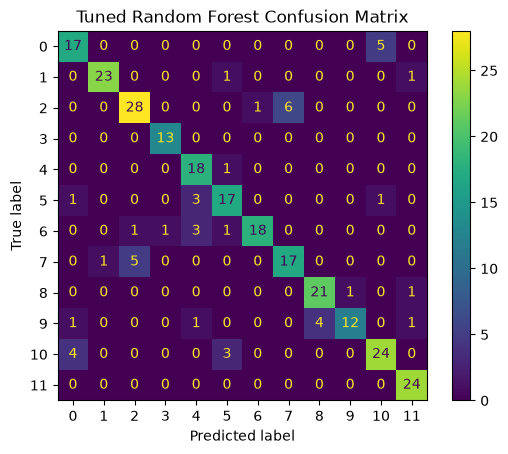

In [33]:
cm = confusion_matrix(y_test, best_rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, best_rf_pred))

                           precision    recall  f1-score   support

              AI Engineer       0.74      0.77      0.76        22
        Backend Developer       0.96      0.92      0.94        25
          Cloud Architect       0.82      0.80      0.81        35
    Cybersecurity Analyst       0.93      1.00      0.96        13
             Data Analyst       0.72      0.95      0.82        19
           Data Scientist       0.74      0.77      0.76        22
   Database Administrator       0.95      0.75      0.84        24
          DevOps Engineer       0.74      0.74      0.74        23
       Frontend Developer       0.84      0.91      0.88        23
     Full Stack Developer       0.92      0.63      0.75        19
Machine Learning Engineer       0.80      0.77      0.79        31
     Mobile App Developer       0.89      1.00      0.94        24

                 accuracy                           0.83       280
                macro avg       0.84      0.84      0.83    

In [35]:
joblib.dump(best_rf, r'C:\Users\divya\Desktop\Team parakh\final_model.pkl')

['C:\\Users\\divya\\Desktop\\Team parakh\\final_model.pkl']

In [36]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, dt_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, best_rf_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, dt_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, best_rf_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, dt_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, best_rf_pred, average="weighted")
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.842857,0.844966,0.842857,0.842154
1,Decision Tree,0.678571,0.687341,0.678571,0.675883
2,Random Forest,0.835714,0.845754,0.835714,0.834382
3,Tuned Random Forest,0.828571,0.834942,0.828571,0.827262


In [37]:
best_model = results_df.loc[results_df["F1 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])

Best Model: Logistic Regression
F1 Score: 0.8421544388360641


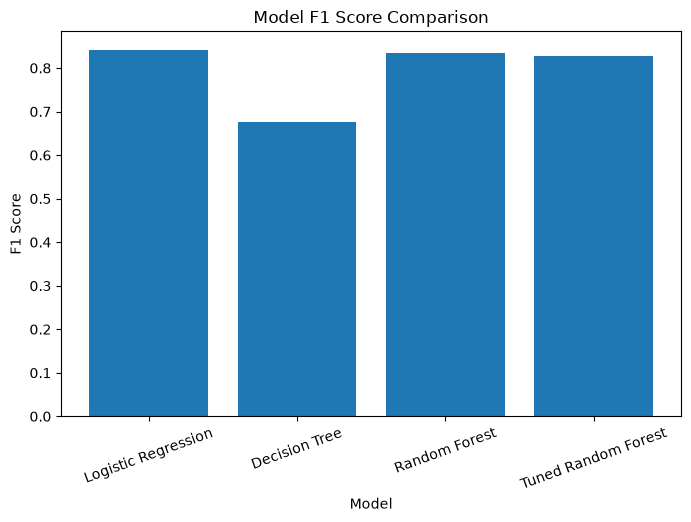

In [38]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("Model F1 Score Comparison")
plt.xticks(rotation=20)
plt.show()

In [39]:
print(classification_report(y_test, best_rf_pred))

                           precision    recall  f1-score   support

              AI Engineer       0.74      0.77      0.76        22
        Backend Developer       0.96      0.92      0.94        25
          Cloud Architect       0.82      0.80      0.81        35
    Cybersecurity Analyst       0.93      1.00      0.96        13
             Data Analyst       0.72      0.95      0.82        19
           Data Scientist       0.74      0.77      0.76        22
   Database Administrator       0.95      0.75      0.84        24
          DevOps Engineer       0.74      0.74      0.74        23
       Frontend Developer       0.84      0.91      0.88        23
     Full Stack Developer       0.92      0.63      0.75        19
Machine Learning Engineer       0.80      0.77      0.79        31
     Mobile App Developer       0.89      1.00      0.94        24

                 accuracy                           0.83       280
                macro avg       0.84      0.84      0.83    

In [40]:
joblib.dump(best_rf,r'C:\Users\divya\Desktop\Team parakh\final_model.pkl')

['C:\\Users\\divya\\Desktop\\Team parakh\\final_model.pkl']

In [ ]:
loaded_model = joblib.load(r'C:\Users\divya\Desktop\parakh\final_model.pkl')
test_prediction = loaded_model.predict(x_test_pca[:5])
print(test_prediction)

['Data Analyst' 'Cloud Architect' 'DevOps Engineer'
 'Machine Learning Engineer' 'DevOps Engineer']


In [42]:
sample = x_test.iloc[:5]

In [43]:
sample_scaled = scaler.transform(sample)

In [44]:
sample_pca = pca.transform(sample_scaled)

In [45]:
sample_prediction = best_rf.predict(sample_pca)
print(sample_prediction)

['Data Analyst' 'Cloud Architect' 'DevOps Engineer'
 'Machine Learning Engineer' 'DevOps Engineer']
